# Smart Waste Classification System — MobileNetV2 Transfer Learning

This notebook trains the computer vision model used by the **Smart Waste** web application.
It classifies a photo of a waste item into one of six categories:

**cardboard · glass · metal · paper · plastic · trash**

| Stage | What happens |
|---|---|
| 1. Environment | Libraries, versions, GPU check, reproducible seed |
| 2. Dataset | Download the public **TrashNet** dataset and organise it into `dataset/<class>/` |
| 3. Analysis | Image counts, class distribution, sample images, image sizes |
| 4. Cleaning | Detect corrupted, unreadable, unsupported and duplicate files |
| 5. Split | Stratified train / validation / test split with a fixed seed |
| 6. Preprocessing | 224 × 224 RGB, MobileNetV2 normalisation embedded in the model |
| 7. Augmentation | Light flips, rotations, zoom, translation and contrast — training only |
| 8. Class weights | Computed from the training split when the classes are imbalanced |
| 9–10. Transfer learning | Frozen MobileNetV2 base + new classification head |
| 11. Curves | Accuracy and loss for training and validation |
| 12. Fine-tuning | Unfreeze the deepest MobileNetV2 blocks, train with a small learning rate |
| 13–15. Evaluation | Untouched test set: accuracy, loss, precision, recall, F1, confusion matrix |
| 16–17. Testing | `predict_image()` and random test predictions |
| 18. Save | `smart_waste_mobilenetv2.keras` |
| 19–21. Web export | Convert to ONNX, verify against Keras, write `metadata.json` for the web app |

**How to run:** in Google Colab choose *Runtime → Change runtime type → T4 GPU*, then *Runtime → Run all*.
Every cell depends only on the cells above it, so the notebook runs top to bottom without edits.
It also runs locally in Jupyter (see `training/requirements.txt`), just more slowly without a GPU.

> **No result in this notebook is pre-filled.** Every number you see is produced when you run it.

## Section 1 — Environment setup

We import the libraries, fix the random seed so the split and training are reproducible, and check for a GPU.

In [1]:
import datetime
import hashlib
import json
import os
import platform
import random
import shutil
import sys
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
import keras
from keras import layers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
keras.utils.set_random_seed(SEED)

IN_COLAB = "google.colab" in sys.modules
WORK_DIR = Path("/content") if IN_COLAB else Path.cwd()
RAW_DIR = WORK_DIR / "trashnet_raw"
DATA_DIR = WORK_DIR / "dataset"
REJECTED_DIR = WORK_DIR / "dataset_rejected"
ARTIFACTS_DIR = WORK_DIR / "artifacts"
CHECKPOINT_DIR = ARTIFACTS_DIR / "checkpoints"
WEB_MODEL_DIR = ARTIFACTS_DIR / "web_model"
for directory in (ARTIFACTS_DIR, CHECKPOINT_DIR, WEB_MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
ALLOWED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print(f"Python        : {sys.version.split()[0]} on {platform.system()} {platform.machine()}")
print(f"TensorFlow    : {tf.__version__}")
print(f"Keras         : {keras.__version__}")
print(f"NumPy         : {np.__version__}")
print(f"scikit-learn  : {sklearn.__version__}")
print(f"Matplotlib    : {matplotlib.__version__}")
print(f"Running in    : {'Google Colab' if IN_COLAB else 'local Jupyter'}")
print(f"Working dir   : {WORK_DIR}")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        print(f"GPU available : {gpu.name}")
else:
    print("GPU available : none — training will run on the CPU and be much slower.")
    if IN_COLAB:
        print("                In Colab use Runtime → Change runtime type → T4 GPU, then rerun.")

Python        : 3.12.10 on Windows AMD64
TensorFlow    : 2.20.0
Keras         : 3.15.1
NumPy         : 2.5.3
scikit-learn  : 1.9.1
Matplotlib    : 3.11.2
Running in    : local Jupyter
Working dir   : C:\Users\User\computer_vision\smart-waste\training
GPU available : none — training will run on the CPU and be much slower.


In [2]:
INK, INK_MUTED, GRID = "#1c1f1d", "#565c58", "#e6e8e3"
COLORS = {
    "train": "#2a78d6",
    "validation": "#eb6834",
    "third": "#1baf7a",
    "brand": "#1f7f40",
    "correct": "#1f7f40",
    "wrong": "#c62828",
}
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d7d0",
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})

## Section 2 — Dataset

### Selected dataset: TrashNet

We use **TrashNet** by Gary Thung and Mindy Yang, created for the Stanford CS229 project
*"Classification of Trash for Recyclability Status"* (2016).

* Source: <https://github.com/garythung/trashnet> (mirror: <https://huggingface.co/datasets/garythung/trashnet>)
* It contains exactly the six classes this project needs: **cardboard, glass, metal, paper, plastic, trash**.
* Each photo shows a single object on a plain white background, so it is clean and well suited to a
  university-level transfer-learning project.
* We use the authors' `dataset-resized.zip` archive (the images resized by the authors to keep the download small, ~43 MB).

**Known limitations — keep these in mind when interpreting results:**

* The dataset is small (a few thousand images), so test metrics have noticeable uncertainty.
* The *trash* class is much smaller than the others (checked below), so we use class weights.
* All photos have plain backgrounds and similar lighting. Real-world photos with cluttered backgrounds
  are a different distribution, and accuracy on them is usually lower than the test accuracy reported here.
* Several photos may show the same physical object from different angles; such near-duplicates can make
  test scores slightly optimistic. Exact duplicates are removed in Section 4.

Please check the repository for the dataset's licence and citation terms before redistributing it.

The cell below downloads the archive (with a fallback mirror), checks its size, extracts it, and copies the
six class folders into:

```
dataset/
├── cardboard/
├── glass/
├── metal/
├── paper/
├── plastic/
└── trash/
```

If `dataset/` is already prepared (for example when you rerun the notebook), the download is skipped.

In [3]:
DATASET_URLS = [
    "https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip",
    "https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip",
]
EXPECTED_ZIP_BYTES = 42_834_870
ZIP_PATH = WORK_DIR / "trashnet-dataset-resized.zip"


def download_dataset(destination):
    if destination.exists() and destination.stat().st_size == EXPECTED_ZIP_BYTES:
        print(f"Archive already present: {destination}")
        return
    errors = []
    for url in DATASET_URLS:
        try:
            print(f"Downloading {url} ...")
            urllib.request.urlretrieve(url, destination)
        except Exception as exc:
            errors.append(f"{url}: {exc}")
            continue
        size = destination.stat().st_size
        if size == EXPECTED_ZIP_BYTES:
            print(f"Downloaded {size / 1e6:.1f} MB")
            return
        errors.append(f"{url}: expected {EXPECTED_ZIP_BYTES} bytes but received {size}")
    raise RuntimeError(
        "TrashNet could not be downloaded from any source:\n  " + "\n  ".join(errors)
        + "\nDownload dataset-resized.zip manually from https://github.com/garythung/trashnet "
        + f"and place it at {destination}."
    )


def find_class_root(root):
    candidates = [root, *sorted(p for p in root.rglob("*") if p.is_dir() and "__MACOSX" not in p.parts)]
    for candidate in candidates:
        child_names = {child.name.lower() for child in candidate.iterdir() if child.is_dir()}
        if set(EXPECTED_CLASSES) <= child_names:
            return candidate
    raise FileNotFoundError(f"No folder inside {root} contains all of: {EXPECTED_CLASSES}")


def dataset_ready():
    return all((DATA_DIR / name).is_dir() and any((DATA_DIR / name).iterdir()) for name in EXPECTED_CLASSES)


def prepare_dataset():
    if dataset_ready():
        print(f"dataset/ is already prepared at {DATA_DIR} — skipping download.")
        return
    download_dataset(ZIP_PATH)
    if RAW_DIR.exists():
        shutil.rmtree(RAW_DIR)
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(RAW_DIR)
    class_root = find_class_root(RAW_DIR)
    print(f"Class folders found inside the archive at: {class_root.relative_to(WORK_DIR)}")
    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
    for name in EXPECTED_CLASSES:
        source = next(child for child in class_root.iterdir() if child.is_dir() and child.name.lower() == name)
        shutil.copytree(source, DATA_DIR / name)
    print(f"Dataset organised into {DATA_DIR}")


prepare_dataset()

Archive already present: C:\Users\User\computer_vision\smart-waste\training\trashnet-dataset-resized.zip


Class folders found inside the archive at: trashnet_raw\dataset-resized


Dataset organised into C:\Users\User\computer_vision\smart-waste\training\dataset


### Verify the dataset and display the six classes

We confirm that every expected class folder exists, report any unexpected folders, and count the files per class.
Files with extensions other than JPG/JPEG/PNG/WEBP are counted separately and handled in Section 4.

In [4]:
found_classes = sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())
missing_classes = sorted(set(EXPECTED_CLASSES) - set(found_classes))
unexpected_classes = sorted(set(found_classes) - set(EXPECTED_CLASSES))

print("Class folders found:", found_classes)
if missing_classes:
    raise RuntimeError(f"Missing class folders: {missing_classes}")
if unexpected_classes:
    print(f"WARNING: unexpected folders will be ignored: {unexpected_classes}")

rows = []
for name in EXPECTED_CLASSES:
    files = [p for p in (DATA_DIR / name).iterdir() if p.is_file()]
    images = [p for p in files if p.suffix.lower() in ALLOWED_EXTENSIONS]
    rows.append({"class": name, "image_files": len(images), "other_files": len(files) - len(images)})

file_counts = pd.DataFrame(rows).set_index("class")
print(f"\nThe six classes: {', '.join(EXPECTED_CLASSES)}\n")
print(file_counts.to_string())
print(f"\nTotal image files: {file_counts['image_files'].sum()}")
if file_counts["other_files"].sum():
    print(f"Non-image files found: {file_counts['other_files'].sum()} (removed during cleaning)")

Class folders found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

The six classes: cardboard, glass, metal, paper, plastic, trash

           image_files  other_files
class                              
cardboard          403            0
glass              501            0
metal              410            0
paper              594            0
plastic            482            0
trash              137            0

Total image files: 2527


## Section 3 — Dataset analysis

Before training we look at the data: how many images each class has, whether the classes are balanced,
what the images look like, and what sizes they are.

Total images: 2527

           images  share_%
class                     
cardboard     403    15.95
glass         501    19.83
metal         410    16.22
paper         594    23.51
plastic       482    19.07
trash         137     5.42

Largest class : paper (594 images)
Smallest class: trash (137 images)
Imbalance ratio (largest / smallest): 4.34
→ The dataset is imbalanced. Class weights will be computed in Section 8.


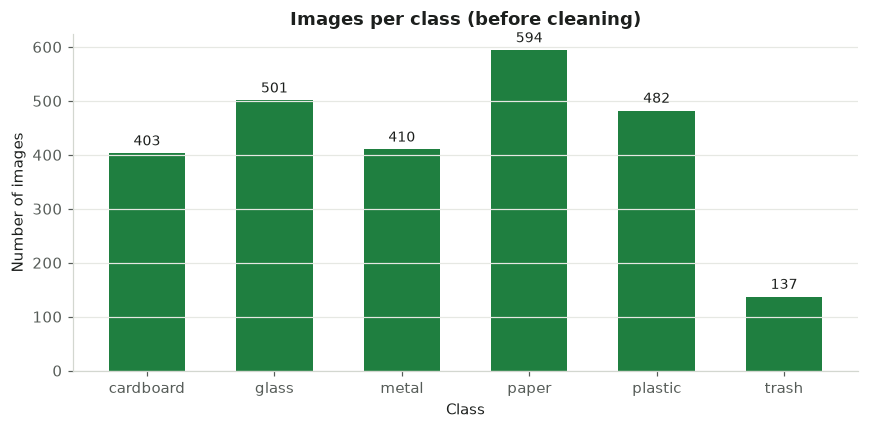

In [5]:
counts = file_counts["image_files"]
total_images = int(counts.sum())
distribution = pd.DataFrame({
    "images": counts,
    "share_%": (counts / total_images * 100).round(2),
})
print(f"Total images: {total_images}\n")
print(distribution.to_string())

imbalance_ratio = counts.max() / counts.min()
print(f"\nLargest class : {counts.idxmax()} ({counts.max()} images)")
print(f"Smallest class: {counts.idxmin()} ({counts.min()} images)")
print(f"Imbalance ratio (largest / smallest): {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print("→ The dataset is imbalanced. Class weights will be computed in Section 8.")
else:
    print("→ The classes are reasonably balanced.")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color=COLORS["brand"], width=0.6)
ax.bar_label(bars, labels=[f"{v}" for v in counts.values], padding=3, color=INK, fontsize=9)
ax.set_title("Images per class (before cleaning)")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

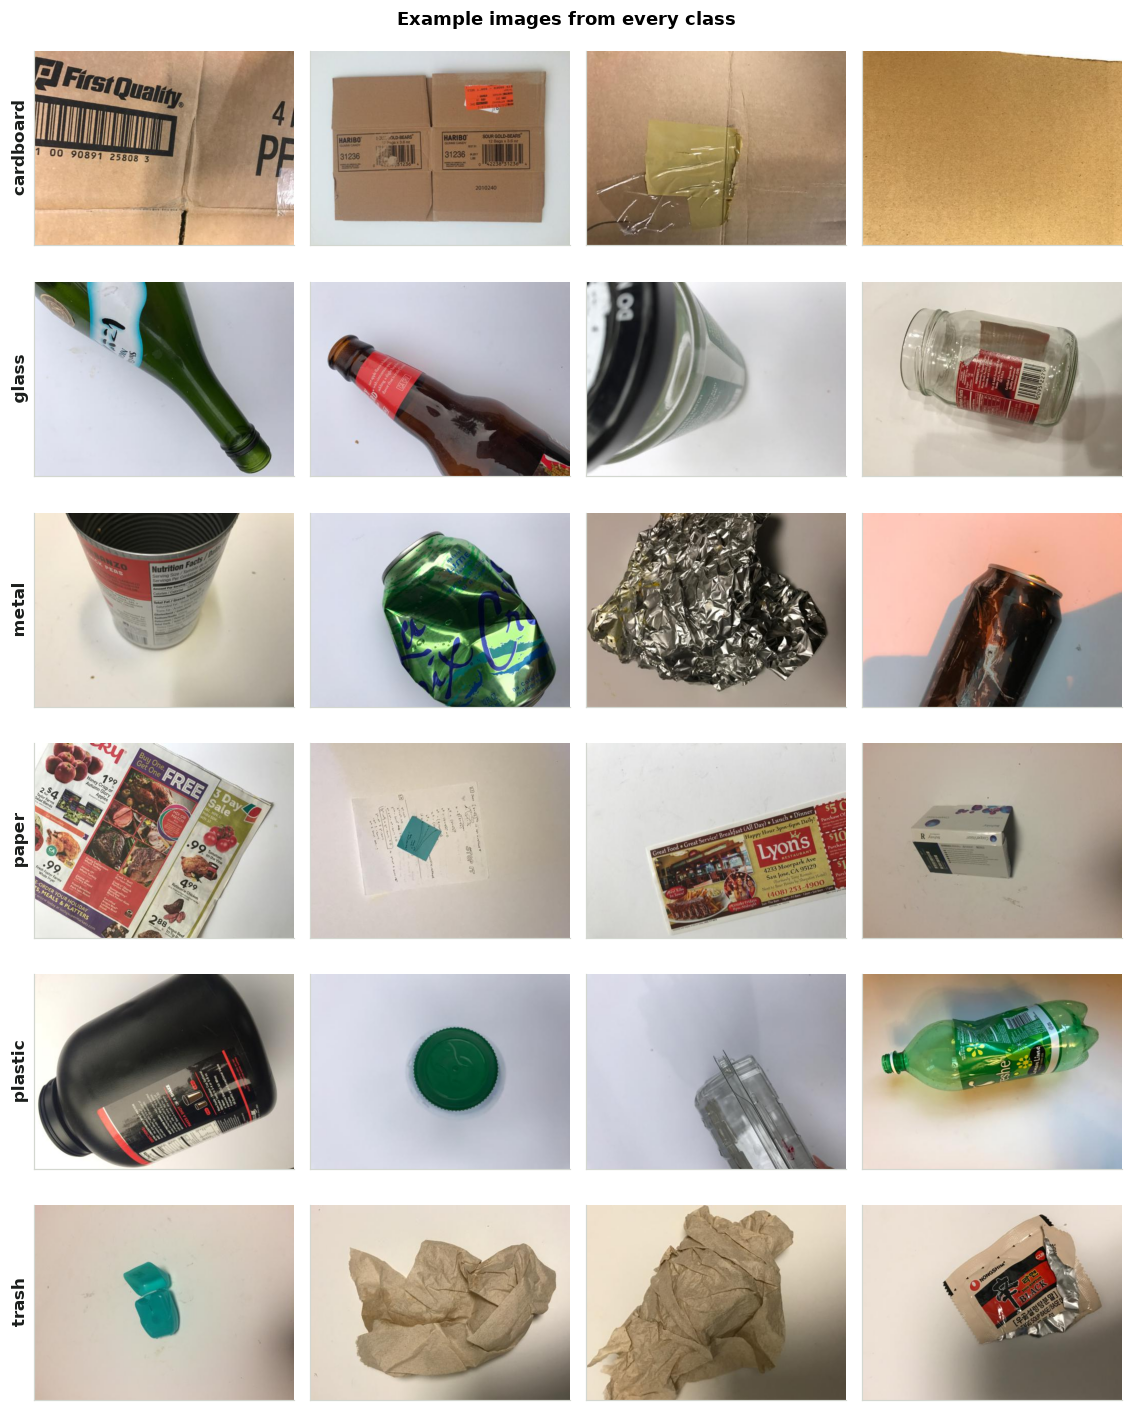

In [6]:
SAMPLES_PER_CLASS = 4
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(len(EXPECTED_CLASSES), SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 2.6, len(EXPECTED_CLASSES) * 2.2))
for row, name in enumerate(EXPECTED_CLASSES):
    images = sorted(p for p in (DATA_DIR / name).iterdir() if p.suffix.lower() in ALLOWED_EXTENSIONS)
    for col, path in enumerate(rng.choice(images, size=SAMPLES_PER_CLASS, replace=False)):
        ax = axes[row, col]
        with Image.open(path) as img:
            ax.imshow(img.convert("RGB"))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if col == 0:
            ax.set_ylabel(name, fontsize=11, fontweight="bold", color=INK)
fig.suptitle("Example images from every class", fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
size_counter = Counter()
mode_counter = Counter()
for name in EXPECTED_CLASSES:
    for path in (DATA_DIR / name).iterdir():
        if path.suffix.lower() not in ALLOWED_EXTENSIONS:
            continue
        try:
            with Image.open(path) as img:
                size_counter[img.size] += 1
                mode_counter[img.mode] += 1
        except (UnidentifiedImageError, OSError):
            size_counter["unreadable"] += 1

print("Most common image sizes (width × height):")
for size, n in size_counter.most_common(5):
    label = size if isinstance(size, str) else f"{size[0]} × {size[1]}"
    print(f"  {label}: {n} images")
print("\nColour modes:", dict(mode_counter))
print(f"\nAll images will be resized to {IMG_SIZE[0]} × {IMG_SIZE[1]} RGB for MobileNetV2.")

Most common image sizes (width × height):
  512 × 384: 2527 images

Colour modes: {'RGB': 2527}

All images will be resized to 224 × 224 RGB for MobileNetV2.


## Section 4 — Dataset cleaning

Each file is checked for:

* an unsupported extension (e.g. hidden system files such as `.DS_Store`),
* an empty file,
* an image that Pillow cannot fully decode (corrupted or truncated),
* an image that TensorFlow cannot decode (TensorFlow is what reads images during training),
* an **exact duplicate** of another image (same bytes). Duplicates are removed because a copy in the
  training set and a copy in the test set would leak information and inflate the test score.

Problem files are **moved** (not deleted) to `dataset_rejected/` so you can inspect them, and every problem is listed.
If more than 5% of the files are rejected the notebook stops, because that indicates a real dataset problem.

In [8]:
def inspect_image(path):
    if path.suffix.lower() not in ALLOWED_EXTENSIONS:
        return "unsupported file type"
    if path.stat().st_size == 0:
        return "empty file"
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB").load()
    except (UnidentifiedImageError, OSError, SyntaxError, ValueError) as exc:
        return f"unreadable by Pillow ({type(exc).__name__})"
    try:
        tf.io.decode_image(tf.io.read_file(str(path)), channels=3, expand_animations=False)
    except (tf.errors.InvalidArgumentError, tf.errors.UnknownError):
        return "unreadable by TensorFlow"
    return None


def file_md5(path):
    return hashlib.md5(path.read_bytes()).hexdigest()


valid_records, rejected = [], []
seen_hashes = {}
for name in EXPECTED_CLASSES:
    for path in sorted((DATA_DIR / name).iterdir()):
        if not path.is_file():
            continue
        problem = inspect_image(path)
        digest = None
        if problem is None:
            digest = file_md5(path)
            if digest in seen_hashes:
                problem = f"exact duplicate of {seen_hashes[digest]}"
            else:
                seen_hashes[digest] = f"{name}/{path.name}"
        if problem:
            rejected.append({"file": f"{name}/{path.name}", "problem": problem})
        else:
            valid_records.append({"path": str(path), "label": name, "md5": digest})

total_files = len(valid_records) + len(rejected)
print(f"Files checked : {total_files}")
print(f"Valid images  : {len(valid_records)}")
print(f"Rejected      : {len(rejected)}")

if rejected:
    rejected_df = pd.DataFrame(rejected)
    print("\nRejected files:")
    print(rejected_df.to_string(index=False))
    for item in rejected:
        source = DATA_DIR / item["file"]
        target = REJECTED_DIR / item["file"]
        target.parent.mkdir(parents=True, exist_ok=True)
        shutil.move(str(source), str(target))
    print(f"\nMoved rejected files to {REJECTED_DIR}")

rejected_share = len(rejected) / max(total_files, 1)
if rejected_share > 0.05:
    raise RuntimeError(
        f"{rejected_share:.1%} of files were rejected — inspect {REJECTED_DIR} before training."
    )

Files checked : 2527
Valid images  : 2524
Rejected      : 3

Rejected files:
                  file                               problem
     metal/metal91.jpg exact duplicate of glass/glass115.jpg
plastic/plastic152.jpg exact duplicate of glass/glass176.jpg
plastic/plastic332.jpg exact duplicate of glass/glass389.jpg

Moved rejected files to C:\Users\User\computer_vision\smart-waste\training\dataset_rejected


In [9]:
records = pd.DataFrame(valid_records)
CLASS_NAMES = sorted(records["label"].unique())
assert CLASS_NAMES == EXPECTED_CLASSES, f"Unexpected classes after cleaning: {CLASS_NAMES}"
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}
records["label_index"] = records["label"].map(CLASS_TO_INDEX)

print("Class-index mapping (this exact order is saved with the model and used by the web app):")
for name, index in CLASS_TO_INDEX.items():
    print(f"  {index} → {name}")
print("\nImages per class after cleaning:")
print(records["label"].value_counts().reindex(CLASS_NAMES).to_string())

Class-index mapping (this exact order is saved with the model and used by the web app):
  0 → cardboard
  1 → glass
  2 → metal
  3 → paper
  4 → plastic
  5 → trash

Images per class after cleaning:
label
cardboard    403
glass        501
metal        409
paper        594
plastic      480
trash        137


## Section 5 — Train / validation / test split

| Split | Share | Used for |
|---|---|---|
| **Training** | 70% | Learning the model weights |
| **Validation** | 15% | Early stopping, learning-rate reduction, choosing the best checkpoint, fine-tuning decisions |
| **Test** | 15% | **Only** the final evaluation in Section 13 — never for training or any decision |

* The split is **stratified**, so each split keeps the same class proportions (important for the small *trash* class).
* `random_state=SEED` makes the split identical every time the notebook is run.
* Exact duplicates were already removed, and the cell below asserts that no file or image content appears in two splits.
* 70/15/15 keeps enough images for training while leaving roughly 70+ test images for the larger classes,
  which is a reasonable compromise for a dataset of this size.

In [10]:
TEST_FRACTION = 0.15
VALIDATION_FRACTION = 0.15

train_val_df, test_df = train_test_split(
    records, test_size=TEST_FRACTION, stratify=records["label"], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VALIDATION_FRACTION / (1 - TEST_FRACTION),
    stratify=train_val_df["label"],
    random_state=SEED,
)
train_df, val_df, test_df = (df.reset_index(drop=True) for df in (train_df, val_df, test_df))

for first, second, label in ((train_df, val_df, "train/validation"), (train_df, test_df, "train/test"), (val_df, test_df, "validation/test")):
    assert not set(first["path"]) & set(second["path"]), f"File overlap between {label}"
    assert not set(first["md5"]) & set(second["md5"]), f"Duplicate image content between {label}"
print("No overlap between splits (checked by file path and by image content hash).\n")

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).reindex(CLASS_NAMES)
split_summary.loc["total"] = split_summary.sum()
print(split_summary.to_string())

for split_name, df in (("train", train_df), ("validation", val_df), ("test", test_df)):
    df.to_csv(ARTIFACTS_DIR / f"split_{split_name}.csv", index=False)
print(f"\nSplit file lists saved to {ARTIFACTS_DIR} for reproducibility.")

No overlap between splits (checked by file path and by image content hash).

           train  validation  test
label                             
cardboard    282          60    61
glass        351          75    75
metal        286          62    61
paper        416          89    89
plastic      336          72    72
trash         95          21    21
total       1766         379   379



Split file lists saved to C:\Users\User\computer_vision\smart-waste\training\artifacts for reproducibility.


## Section 6 — Data preprocessing

MobileNetV2 expects **224 × 224 RGB** images whose pixel values are scaled to **[-1, 1]**
(`keras.applications.mobilenet_v2.preprocess_input` computes `x / 127.5 - 1`).

To guarantee that the website preprocesses images exactly like training does, the scaling step is
**built into the model** as a `Rescaling(1/127.5, offset=-1)` layer. The model therefore accepts plain RGB
pixels in **[0, 255]** — the same values a browser canvas produces — and there is no separate normalisation
step that could be implemented differently in JavaScript.

`load_image()` is the single image-loading function used for training, evaluation and single-image prediction:

1. decode the file as **RGB** (3 channels; any alpha channel is dropped). JPEGs use the accurate integer IDCT
   (`dct_method="INTEGER_ACCURATE"`), which is what web browsers use — TensorFlow's faster default produces
   slightly different pixels than the browser would,
2. resize to 224 × 224 with **bilinear interpolation and antialiasing** (aspect ratio not preserved, like the web app),
3. round to whole 0–255 values, matching the 8-bit pixels a browser canvas returns.

In [11]:
def decode_rgb(contents):
    return tf.cond(
        tf.io.is_jpeg(contents),
        lambda: tf.io.decode_jpeg(contents, channels=3, dct_method="INTEGER_ACCURATE"),
        lambda: tf.io.decode_image(contents, channels=3, expand_animations=False),
    )


def load_image(path):
    image = decode_rgb(tf.io.read_file(path))
    image = tf.image.resize(image, IMG_SIZE, method="bilinear", antialias=True)
    image = tf.cast(tf.clip_by_value(tf.round(image), 0, 255), tf.uint8)
    image.set_shape((*IMG_SIZE, 3))
    return image


mobilenet_preprocessing = layers.Rescaling(1 / 127.5, offset=-1.0, name="mobilenetv2_preprocess")

check_pixels = np.random.default_rng(SEED).uniform(0, 255, size=(2, *IMG_SIZE, 3)).astype("float32")
expected = keras.applications.mobilenet_v2.preprocess_input(check_pixels.copy())
np.testing.assert_allclose(keras.ops.convert_to_numpy(mobilenet_preprocessing(check_pixels)), expected, atol=1e-5)
print("Rescaling(1/127.5, offset=-1) matches mobilenet_v2.preprocess_input exactly.")

sample = load_image(train_df["path"][0])
print(f"Loaded sample: shape={tuple(sample.shape)}, dtype={sample.dtype.name}, "
      f"range=[{int(tf.reduce_min(sample))}, {int(tf.reduce_max(sample))}]")

Rescaling(1/127.5, offset=-1) matches mobilenet_v2.preprocess_input exactly.
Loaded sample: shape=(224, 224, 3), dtype=uint8, range=[43, 248]


## Section 7 — Data augmentation

Augmentation creates slightly different versions of each training image every epoch, which helps the model
generalise from a small dataset. The transformations are deliberately **mild** so the object stays recognisable:

| Layer | Setting | Why |
|---|---|---|
| `RandomFlip("horizontal")` | left/right mirror | Waste items have no fixed left/right orientation |
| `RandomRotation(0.05)` | up to ±18° | Photos are rarely perfectly level |
| `RandomZoom(0.10)` | ±10% | Items appear at different distances |
| `RandomTranslation(0.08, 0.08)` | ±8% | Items are not always centred |
| `RandomContrast(0.15)` | ±15% | Lighting differs between photos |

No vertical flips, strong colour shifts or heavy distortions are used: colour and texture are key cues for
telling glass, plastic and metal apart.

The augmentation layers are part of the model (right after the input). Keras only applies them while
training; during validation, testing and in the exported web model they pass images through unchanged.

Training batch: images (32, 224, 224, 3) float32, labels (32,)


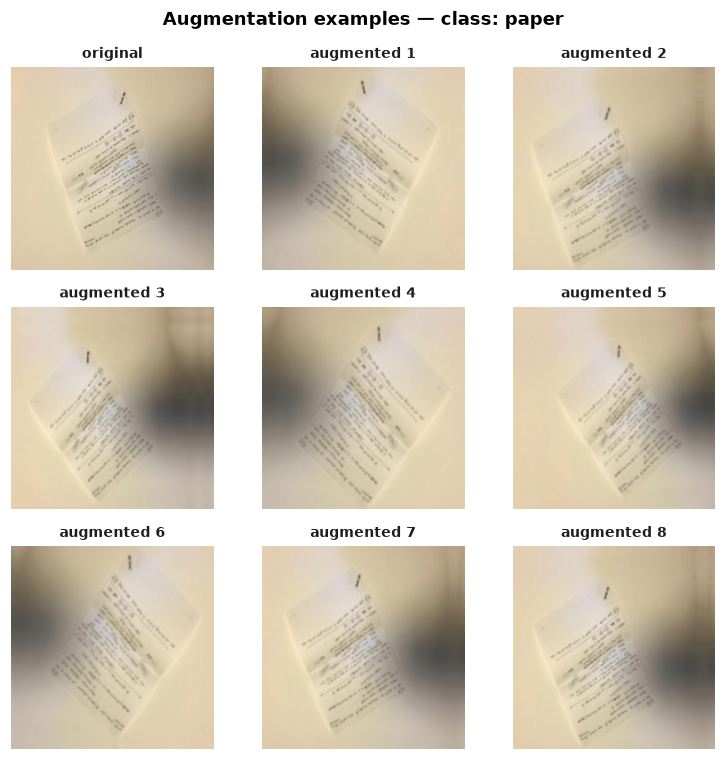

In [12]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, fill_mode="reflect", seed=SEED),
        layers.RandomZoom(0.10, fill_mode="reflect", seed=SEED),
        layers.RandomTranslation(0.08, 0.08, fill_mode="reflect", seed=SEED),
        layers.RandomContrast(0.15, seed=SEED),
    ],
    name="data_augmentation",
)


def make_dataset(df, shuffle):
    paths = df["path"].astype(str).to_numpy()
    labels = df["label_index"].astype("int32").to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(lambda path, label: (load_image(path), label), num_parallel_calls=AUTOTUNE).cache()
    if shuffle:
        dataset = dataset.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.batch(BATCH_SIZE).map(lambda images, labels: (tf.cast(images, tf.float32), labels))
    return dataset.prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

for images, labels in train_ds.take(1):
    print(f"Training batch: images {tuple(images.shape)} {images.dtype.name}, labels {tuple(labels.shape)}")

example = tf.cast(load_image(train_df["path"][0]), tf.float32)[tf.newaxis]
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    shown = example[0] if i == 0 else data_augmentation(example, training=True)[0]
    ax.imshow(np.clip(keras.ops.convert_to_numpy(shown), 0, 255).astype("uint8"))
    ax.set_title("original" if i == 0 else f"augmented {i}", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Augmentation examples — class: {train_df['label'][0]}", fontweight="bold")
plt.tight_layout()
plt.show()

## Section 8 — Handling class imbalance

When one class has far fewer images, the model can score well by mostly ignoring it.
**Class weights** make each mistake on a rare class count more in the loss.

The weights are computed by scikit-learn from the **training split only** using the `"balanced"` formula
`n_samples / (n_classes × n_samples_in_class)`. They are applied when the largest training class is more than
1.5× the smallest.

In [13]:
train_labels = train_df["label_index"].to_numpy()
weights = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_labels)
train_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
train_imbalance = train_counts.max() / train_counts.min()

USE_CLASS_WEIGHTS = bool(train_imbalance > 1.5)
CLASS_WEIGHTS = {int(i): float(w) for i, w in enumerate(weights)} if USE_CLASS_WEIGHTS else None

print(pd.DataFrame({"train_images": train_counts, "class_weight": weights.round(3)}, index=CLASS_NAMES).to_string())
print(f"\nTraining imbalance ratio: {train_imbalance:.2f}")
print("Class weights WILL be used." if USE_CLASS_WEIGHTS else "Classes are balanced enough; class weights will not be used.")

           train_images  class_weight
cardboard           282         1.044
glass               351         0.839
metal               286         1.029
paper               416         0.708
plastic             336         0.876
trash                95         3.098

Training imbalance ratio: 4.38
Class weights WILL be used.


## Section 9 — MobileNetV2 transfer learning

**Transfer learning** reuses a network that has already learned general visual features (edges, textures,
shapes) from the 1.2 million ImageNet images. We keep those features and only train a new classifier on top.

```
Input (224 × 224 × 3, RGB 0–255)
  ↓ Data augmentation (training only)
  ↓ Rescaling to [-1, 1]  (MobileNetV2 preprocessing, inside the model)
  ↓ MobileNetV2 base, ImageNet weights, frozen
  ↓ GlobalAveragePooling2D
  ↓ Dropout(0.2)
  ↓ Dense(256, ReLU, L2 regularisation)
  ↓ Dropout(0.4)
  ↓ Dense(6, softmax)  → probabilities for the six classes
```

Regularisation against over-fitting: dropout, L2 weight decay on the dense layer, data augmentation and early stopping.
The base model is called with `training=False` so its BatchNormalization layers always use their ImageNet statistics,
which is the recommended setting for fine-tuning later.

In [14]:
base_model = keras.applications.MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
x = data_augmentation(inputs)
x = mobilenet_preprocessing(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.2, name="dropout_features")(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4), name="dense_head")(x)
x = layers.Dropout(0.4, name="dropout_head")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="probabilities")(x)
model = keras.Model(inputs, outputs, name="smart_waste_mobilenetv2")

model.summary(show_trainable=True)


def count_params(weights):
    return int(sum(np.prod(w.shape) for w in weights))


print(f"MobileNetV2 layers: {len(base_model.layers)}")
print(f"Trainable parameters    : {count_params(model.trainable_weights):,}")
print(f"Non-trainable parameters: {count_params(model.non_trainable_weights):,}")

Model: "smart_waste_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ image (InputLayer)          │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ data_augmentation           │ (None, 224, 224, 3)   │          0 │   -   │
│ (Sequential)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_preprocess      │ (None, 224, 224, 3)   │          0 │   -   │
│ (Rescaling)                 │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling      │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_features (Dropout)  │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_head (Dense)          │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_head (Dropout)      │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ probabilities (Dense)       │ (None, 6)             │      1,542 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 layers: 154
Trainable parameters    : 329,478
Non-trainable parameters: 2,257,984


## Section 10 — Initial training (frozen base)

* **Optimizer:** Adam with learning rate `1e-3` — a standard choice for training a new head.
* **Loss:** sparse categorical cross-entropy (labels are integer class indices).
* **Metric:** accuracy.
* **Callbacks** (all monitor the **validation** loss, never the test set):
  * `EarlyStopping(patience=5, restore_best_weights=True)` — stops when validation loss stops improving.
  * `ReduceLROnPlateau(factor=0.3, patience=2)` — lowers the learning rate when progress stalls.
  * `ModelCheckpoint(save_best_only=True)` — keeps the best model on disk.

In [15]:
INITIAL_EPOCHS = 25
HEAD_CHECKPOINT = CHECKPOINT_DIR / "head_best.keras"
FINETUNE_CHECKPOINT = CHECKPOINT_DIR / "finetune_best.keras"
for checkpoint in (HEAD_CHECKPOINT, FINETUNE_CHECKPOINT):
    checkpoint.unlink(missing_ok=True)


def make_callbacks(checkpoint_path, initial_value_threshold=None):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            initial_value_threshold=initial_value_threshold,
            verbose=1,
        ),
    ]


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=CLASS_WEIGHTS,
    verbose=2,
    callbacks=make_callbacks(HEAD_CHECKPOINT),
)
head_epochs_run = len(history_head.history["loss"])
best_head_val_loss = float(min(history_head.history["val_loss"]))
print(f"\nHead training ran for {head_epochs_run} epochs. Best validation loss: {best_head_val_loss:.4f}")

Epoch 1/25


C:\Users\User\computer_vision\.venv-training\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(



Epoch 1: val_loss improved from None to 0.78368, saving model to C:\Users\User\computer_vision\smart-waste\training\artifacts\checkpoints\head_best.keras



Epoch 1: finished saving model to C:\Users\User\computer_vision\smart-waste\training\artifacts\checkpoints\head_best.keras


56/56 - 49s - 879ms/step - accuracy: 0.5589 - loss: 1.2649 - val_accuracy: 0.7098 - val_loss: 0.7837 - learning_rate: 0.0010


...


Epoch 16: val_loss did not improve from 0.55183


56/56 - 36s - 650ms/step - accuracy: 0.9071 - loss: 0.3015 - val_accuracy: 0.8285 - val_loss: 0.5531 - learning_rate: 8.1000e-06


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 11.



Head training ran for 16 epochs. Best validation loss: 0.5518


## Section 11 — Training visualisation

How to read the curves:

* **Training and validation both improving and close together** → healthy learning.
* **Training keeps improving while validation gets worse** → over-fitting (the model memorises the training images).
* **Both stay poor** → under-fitting (the model is too constrained or needs more training).

Validation accuracy can be *higher* than training accuracy here because dropout and augmentation are active
only during training, which makes the training task harder.

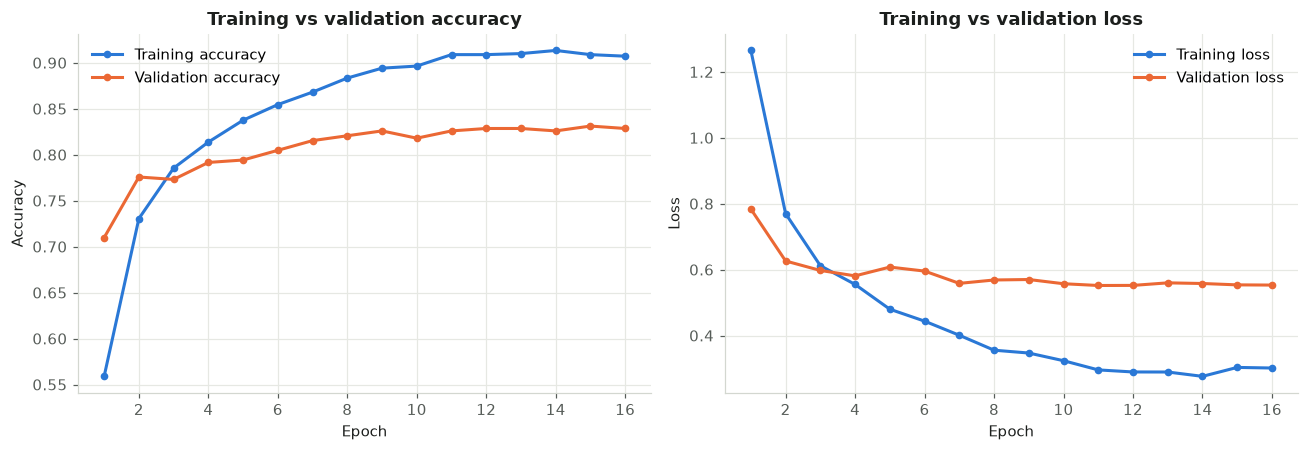

Last epoch — training accuracy: 0.9071, validation accuracy: 0.8285, gap: +0.0786


In [16]:
def plot_history(histories, fine_tune_start=None):
    merged = {key: sum((h.history[key] for h in histories), []) for key in ("accuracy", "val_accuracy", "loss", "val_loss")}
    epochs = np.arange(1, len(merged["loss"]) + 1)
    fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 4.2))
    panels = ((ax_acc, "accuracy", "Accuracy"), (ax_loss, "loss", "Loss"))
    for ax, key, title in panels:
        ax.plot(epochs, merged[key], color=COLORS["train"], linewidth=2, marker="o", markersize=4, label=f"Training {title.lower()}")
        ax.plot(epochs, merged[f"val_{key}"], color=COLORS["validation"], linewidth=2, marker="o", markersize=4, label=f"Validation {title.lower()}")
        if fine_tune_start is not None:
            ax.axvline(fine_tune_start + 0.5, color=INK_MUTED, linestyle="--", linewidth=1)
            ax.text(fine_tune_start + 0.7, ax.get_ylim()[1], "fine-tuning starts", va="top", fontsize=8, color=INK_MUTED)
        ax.set_title(f"Training vs validation {title.lower()}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.legend()
    plt.tight_layout()
    return fig


plot_history([history_head])
plt.show()

final_train_acc = history_head.history["accuracy"][-1]
final_val_acc = history_head.history["val_accuracy"][-1]
print(f"Last epoch — training accuracy: {final_train_acc:.4f}, validation accuracy: {final_val_acc:.4f}, "
      f"gap: {final_train_acc - final_val_acc:+.4f}")

## Section 12 — Fine-tuning

The frozen base already gives good features, but they were learned for ImageNet objects. Fine-tuning lets the
**deepest** MobileNetV2 layers adapt to waste materials.

* **Only the last blocks are unfrozen** (from `block_13_expand` to the end — roughly the top quarter of the
  network). Early layers detect generic edges and textures that are useful as they are; the deep layers
  encode more task-specific patterns. Unfreezing everything on a few thousand images would risk destroying
  the pretrained features and over-fitting.
* **BatchNormalization layers stay frozen**, so their ImageNet statistics are not disturbed by small batches.
* **Learning rate 1e-5** (100× smaller) makes small, careful updates to the pretrained weights.
* The fine-tuning checkpoint is only saved if it **beats the best validation loss from Section 10**; otherwise
  the head-only model is kept. This decision uses validation data only.

In [17]:
FINE_TUNE_FROM_LAYER = "block_13_expand"
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LEARNING_RATE = 1e-5

base_model.trainable = True
layer_names = [layer.name for layer in base_model.layers]
fine_tune_at = layer_names.index(FINE_TUNE_FROM_LAYER)
for index, layer in enumerate(base_model.layers):
    layer.trainable = index >= fine_tune_at and not isinstance(layer, layers.BatchNormalization)

unfrozen = [layer.name for layer in base_model.layers if layer.trainable]
print(f"Unfreezing MobileNetV2 from layer {fine_tune_at} ('{FINE_TUNE_FROM_LAYER}') of {len(base_model.layers)}")
print(f"Trainable MobileNetV2 layers: {len(unfrozen)} (BatchNormalization layers kept frozen)")
print(f"Trainable parameters now: {count_params(model.trainable_weights):,}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=head_epochs_run + FINE_TUNE_EPOCHS,
    initial_epoch=head_epochs_run,
    class_weight=CLASS_WEIGHTS,
    verbose=2,
    callbacks=make_callbacks(FINETUNE_CHECKPOINT, initial_value_threshold=best_head_val_loss),
)
fine_epochs_run = len(history_fine.history["loss"])

Unfreezing MobileNetV2 from layer 116 ('block_13_expand') of 154
Trainable MobileNetV2 layers: 25 (BatchNormalization layers kept frozen)
Trainable parameters now: 1,992,838
Epoch 17/36



Epoch 17: val_loss did not improve from 0.55183


56/56 - 52s - 924ms/step - accuracy: 0.8986 - loss: 0.3156 - val_accuracy: 0.8522 - val_loss: 0.5649 - learning_rate: 1.0000e-05


Epoch 18/36



Epoch 18: val_loss did not improve from 0.55183


...

Epoch 33/36



Epoch 33: val_loss did not improve from 0.51481


56/56 - 41s - 728ms/step - accuracy: 0.9422 - loss: 0.1964 - val_accuracy: 0.8443 - val_loss: 0.5246 - learning_rate: 1.0000e-07


Epoch 33: early stopping


Restoring model weights from the end of the best epoch: 28.


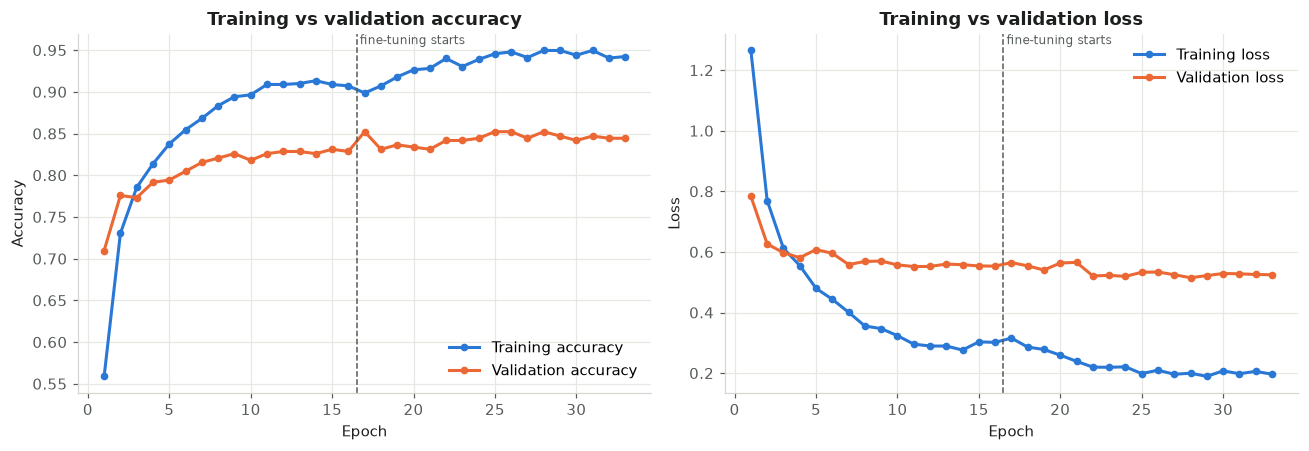

Selected model: fine-tuned
Validation loss 0.5148, validation accuracy 0.8522


In [18]:
fig = plot_history([history_head, history_fine], fine_tune_start=head_epochs_run)
fig.savefig(ARTIFACTS_DIR / "training_curves.png", bbox_inches="tight")
plt.show()

if FINETUNE_CHECKPOINT.exists():
    selected_checkpoint, selected_stage = FINETUNE_CHECKPOINT, "fine-tuned"
else:
    selected_checkpoint, selected_stage = HEAD_CHECKPOINT, "head-only (fine-tuning did not improve validation loss)"
final_model = keras.models.load_model(selected_checkpoint)

best_val_loss, best_val_accuracy = final_model.evaluate(val_ds, verbose=0)
print(f"Selected model: {selected_stage}")
print(f"Validation loss {best_val_loss:.4f}, validation accuracy {best_val_accuracy:.4f}")

pd.DataFrame({key: history_head.history[key] + history_fine.history[key] for key in ("accuracy", "val_accuracy", "loss", "val_loss")}).to_csv(
    ARTIFACTS_DIR / "training_history.csv", index_label="epoch_index"
)

## Section 13 — Final evaluation on the untouched test set

This is the **first and only time** the test set is used. Nothing was tuned on it, so these numbers are an honest
estimate of performance on new images *from the same distribution as TrashNet*.

* **Precision** — of the images predicted as a class, how many really are that class.
* **Recall** — of the images that really are a class, how many the model found.
* **F1-score** — the harmonic mean of precision and recall.
* **Macro average** treats every class equally (important for the small *trash* class);
  **weighted average** weights classes by their number of test images.

In [19]:
test_loss, test_accuracy = final_model.evaluate(test_ds, verbose=0)
y_prob = final_model.predict(test_ds, verbose=0)
y_pred = y_prob.argmax(axis=1)
y_true = test_df["label_index"].to_numpy()

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
assert abs(accuracy_score(y_true, y_pred) - test_accuracy) < 1e-6

metrics = {
    "test_samples": int(len(y_true)),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_p),
    "macro_recall": float(macro_r),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p),
    "weighted_recall": float(weighted_r),
    "weighted_f1": float(weighted_f1),
}
print(f"Test images      : {metrics['test_samples']}")
print(f"Test loss        : {test_loss:.4f}")
print(f"Test accuracy    : {test_accuracy:.4f}")
print(f"Macro precision  : {macro_p:.4f}")
print(f"Macro recall     : {macro_r:.4f}")
print(f"Macro F1-score   : {macro_f1:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}\n")

report_text = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0)
print(report_text)
(ARTIFACTS_DIR / "classification_report.txt").write_text(report_text)
(ARTIFACTS_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))

Test images      : 379
Test loss        : 0.4578
Test accuracy    : 0.8602
Macro precision  : 0.8391
Macro recall     : 0.8255
Macro F1-score   : 0.8308
Weighted F1-score: 0.8588

              precision    recall  f1-score   support

   cardboard     0.9167    0.9016    0.9091        61
       glass     0.8608    0.9067    0.8831        75
       metal     0.8308    0.8852    0.8571        61
       paper     0.9205    0.9101    0.9153        89
     plastic     0.8000    0.7778    0.7887        72
       trash     0.7059    0.5714    0.6316        21

    accuracy                         0.8602       379
   macro avg     0.8391    0.8255    0.8308       379
weighted avg     0.8588    0.8602    0.8588       379



333

## Section 14 — Confusion matrix

Rows are the **true** classes and columns the **predicted** classes. The diagonal holds correct predictions.
The right-hand matrix is normalised per row, so each row shows how a true class was distributed across predictions
(the diagonal equals per-class recall).

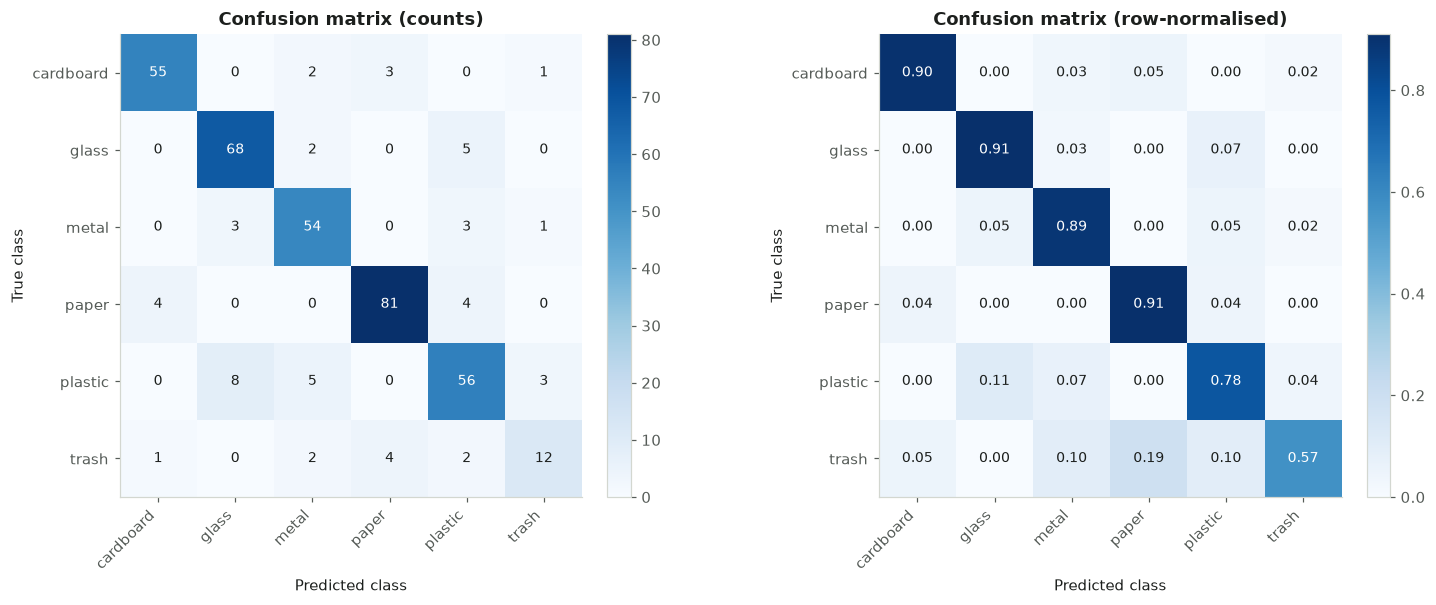

Most common confusions:
   true predicted_as  count  share_of_true_class
plastic        glass      8               0.1111
plastic        metal      5               0.0694
  glass      plastic      5               0.0667
  trash        paper      4               0.1905
  paper    cardboard      4               0.0449
  paper      plastic      4               0.0449
plastic        trash      3               0.0417
  metal        glass      3               0.0492


In [20]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
cm_normalised = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
for ax, matrix, title, fmt in ((axes[0], cm, "Confusion matrix (counts)", "d"), (axes[1], cm_normalised, "Confusion matrix (row-normalised)", ".2f")):
    image = ax.imshow(matrix, cmap="Blues", vmin=0)
    ax.set_xticks(np.arange(NUM_CLASSES), labels=CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(np.arange(NUM_CLASSES), labels=CLASS_NAMES)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    ax.grid(False)
    threshold = matrix.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(matrix[i, j], fmt), ha="center", va="center", fontsize=9,
                    color="white" if matrix[i, j] > threshold else INK)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

confusions = [
    {"true": CLASS_NAMES[i], "predicted_as": CLASS_NAMES[j], "count": int(cm[i, j]), "share_of_true_class": round(cm_normalised[i, j], 4)}
    for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j and cm[i, j] > 0
]
confusions_df = pd.DataFrame(confusions)
if confusions_df.empty:
    print("No misclassifications on the test set.")
else:
    print("Most common confusions:")
    print(confusions_df.sort_values("count", ascending=False).head(8).to_string(index=False))

## Section 15 — Per-class performance

The table and chart show precision, recall and F1-score for every class, sorted from weakest to strongest F1.
Classes with an F1-score below 0.80 are flagged as needing improvement — they are reported, not hidden.

           precision  recall  f1_score  support
trash         0.7059  0.5714    0.6316       21
plastic       0.8000  0.7778    0.7887       72
metal         0.8308  0.8852    0.8571       61
glass         0.8608  0.9067    0.8831       75
cardboard     0.9167  0.9016    0.9091       61
paper         0.9205  0.9101    0.9153       89

Strongest class: paper (F1 0.9153)
Weakest class  : trash (F1 0.6316)
Classes below F1 0.80 (need improvement): trash, plastic


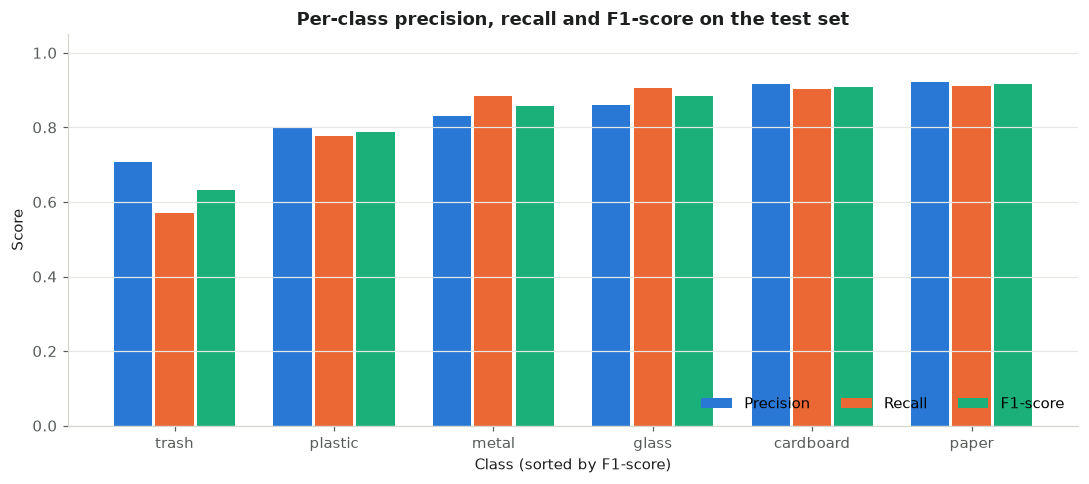

In [21]:
p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=np.arange(NUM_CLASSES), zero_division=0)
per_class = pd.DataFrame({"precision": p, "recall": r, "f1_score": f1, "support": support}, index=CLASS_NAMES).sort_values("f1_score")
print(per_class.round(4).to_string())
per_class.to_csv(ARTIFACTS_DIR / "per_class_metrics.csv")

strongest, weakest = per_class.index[-1], per_class.index[0]
print(f"\nStrongest class: {strongest} (F1 {per_class.loc[strongest, 'f1_score']:.4f})")
print(f"Weakest class  : {weakest} (F1 {per_class.loc[weakest, 'f1_score']:.4f})")
needs_work = per_class[per_class["f1_score"] < 0.80]
if needs_work.empty:
    print("All classes reach an F1-score of at least 0.80.")
else:
    print(f"Classes below F1 0.80 (need improvement): {', '.join(needs_work.index)}")

fig, ax = plt.subplots(figsize=(10, 4.5))
positions = np.arange(len(per_class))
width = 0.26
for offset, column, color, label in ((-width, "precision", COLORS["train"], "Precision"), (0, "recall", COLORS["validation"], "Recall"), (width, "f1_score", COLORS["third"], "F1-score")):
    ax.bar(positions + offset, per_class[column], width=width - 0.02, color=color, label=label)
ax.set_xticks(positions, labels=per_class.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_xlabel("Class (sorted by F1-score)")
ax.set_title("Per-class precision, recall and F1-score on the test set")
ax.grid(axis="x", visible=False)
ax.legend(ncol=3, loc="lower right")
plt.tight_layout()
plt.show()

## Section 16 — Individual image testing

`predict_image(image_path, actual_label=None)` loads an image with the **same `load_image()` function** used for
training, runs the final model, and shows the image, the predicted class, the confidence and the probability of
every class. All values come directly from the model's softmax output.

To try your own photo in Colab, set `UPLOAD_OWN_IMAGE = True` and choose an image file from your computer.

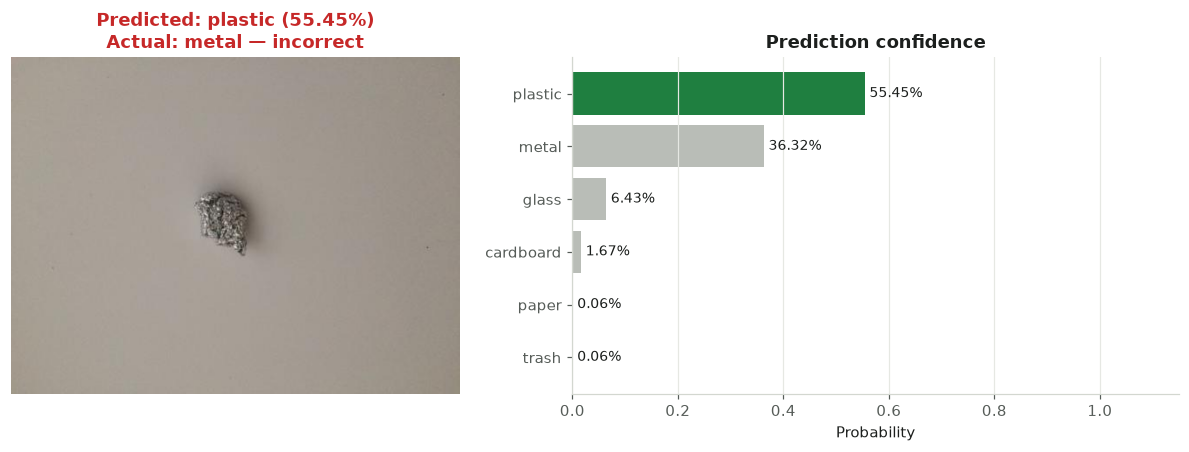

Prediction: Plastic
Confidence: 55.45%

Cardboard  1.67%
Glass      6.43%
Metal      36.32%
Paper      0.06%
Plastic    55.45%
Trash      0.06%


In [22]:
def predict_image(image_path, actual_label=None, model_to_use=None):
    model_to_use = model_to_use or final_model
    image = load_image(str(image_path))
    probabilities = model_to_use.predict(tf.cast(image, tf.float32)[tf.newaxis], verbose=0)[0]
    order = np.argsort(probabilities)[::-1]
    predicted = CLASS_NAMES[order[0]]
    confidence = float(probabilities[order[0]])

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.3]})
    with Image.open(image_path) as original:
        ax_img.imshow(original.convert("RGB"))
    ax_img.axis("off")
    title = f"Predicted: {predicted} ({confidence:.2%})"
    if actual_label is not None:
        correct = actual_label == predicted
        title += f"\nActual: {actual_label} — {'correct' if correct else 'incorrect'}"
        ax_img.set_title(title, color=COLORS["correct"] if correct else COLORS["wrong"])
    else:
        ax_img.set_title(title)

    names = [CLASS_NAMES[i] for i in order][::-1]
    values = probabilities[order][::-1]
    bar_colors = [COLORS["brand"] if name == predicted else "#b9bdb7" for name in names]
    bars = ax_bar.barh(names, values, color=bar_colors)
    ax_bar.bar_label(bars, labels=[f"{v:.2%}" for v in values], padding=3, fontsize=9, color=INK)
    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel("Probability")
    ax_bar.set_title("Prediction confidence")
    ax_bar.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()

    print(f"Prediction: {predicted.capitalize()}")
    print(f"Confidence: {confidence:.2%}\n")
    for index, name in enumerate(CLASS_NAMES):
        print(f"{name.capitalize():<10} {probabilities[index]:.2%}")
    return {"predicted": predicted, "confidence": confidence, "probabilities": dict(zip(CLASS_NAMES, map(float, probabilities)))}


example_row = test_df.sample(1, random_state=SEED).iloc[0]
_ = predict_image(example_row["path"], actual_label=example_row["label"])

In [23]:
UPLOAD_OWN_IMAGE = False

if UPLOAD_OWN_IMAGE:
    if IN_COLAB:
        from google.colab import files

        uploaded = files.upload()
        for file_name in uploaded:
            predict_image(WORK_DIR / file_name)
    else:
        print("Outside Colab, call predict_image('path/to/image.jpg') directly.")

## Section 17 — Random test samples

Twelve random images from the untouched test set with their actual class, predicted class and confidence.
Green titles are correct predictions, red titles are mistakes.

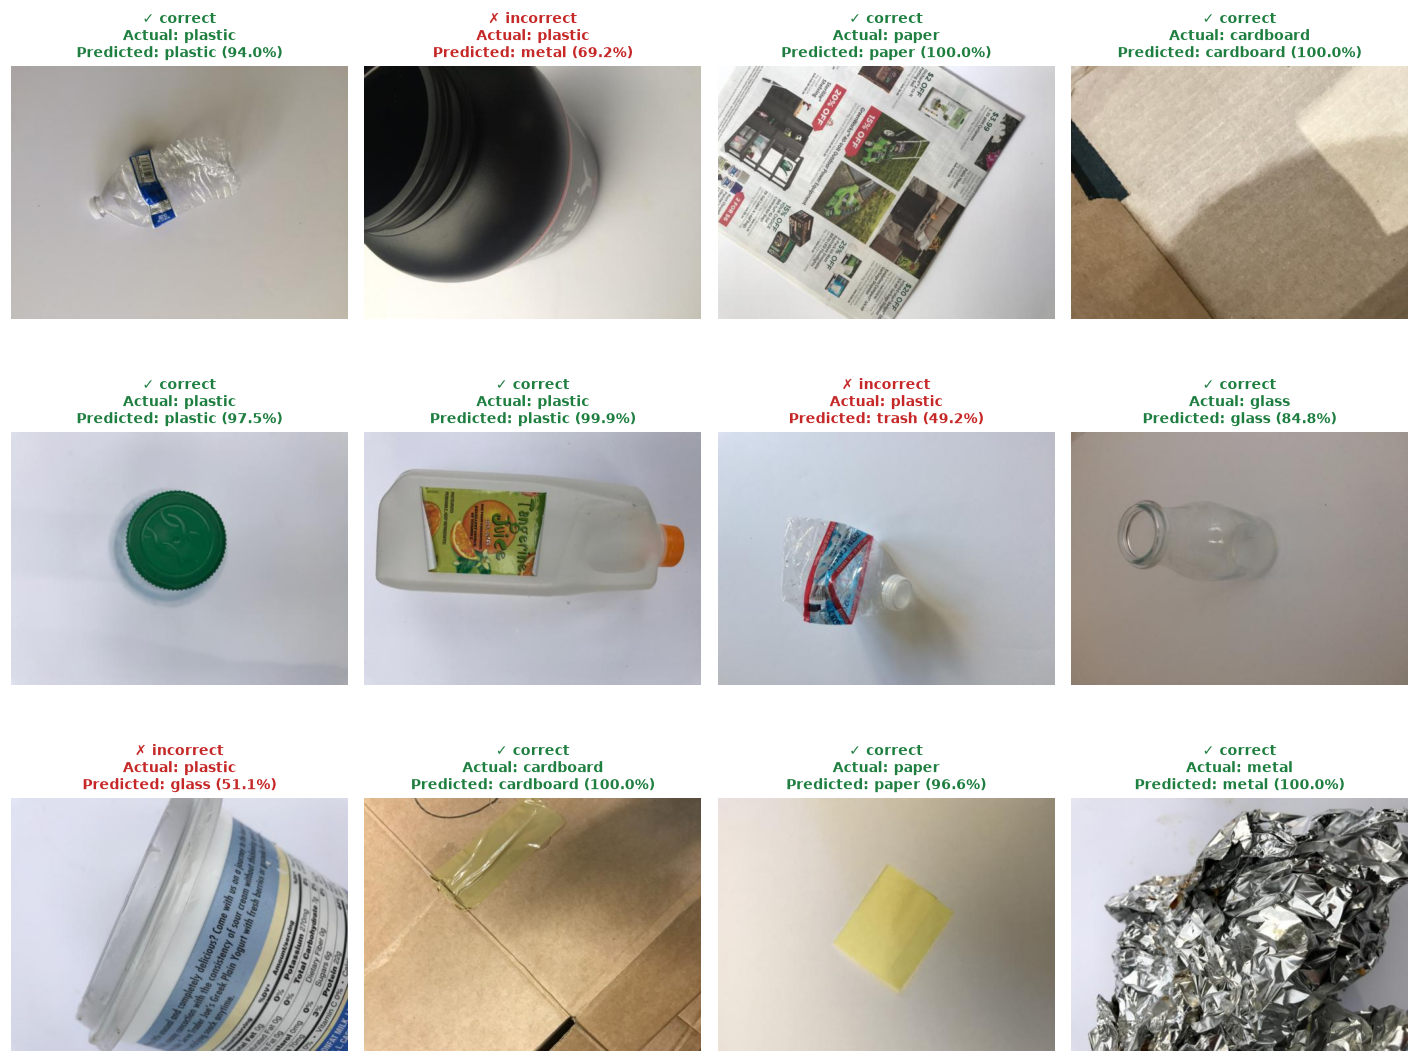

Correct in this sample: 9 / 12


In [24]:
sample_indices = np.random.default_rng(SEED).choice(len(test_df), size=min(12, len(test_df)), replace=False)
fig, axes = plt.subplots(3, 4, figsize=(13, 10.5))
for ax, index in zip(axes.flat, sample_indices):
    row = test_df.iloc[index]
    predicted = CLASS_NAMES[y_pred[index]]
    confidence = y_prob[index, y_pred[index]]
    correct = predicted == row["label"]
    with Image.open(row["path"]) as img:
        ax.imshow(img.convert("RGB"))
    ax.set_title(
        f"{'✓ correct' if correct else '✗ incorrect'}\nActual: {row['label']}\nPredicted: {predicted} ({confidence:.1%})",
        fontsize=9,
        color=COLORS["correct"] if correct else COLORS["wrong"],
    )
    ax.axis("off")
for ax in list(axes.flat)[len(sample_indices):]:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Correct in this sample: {sum(CLASS_NAMES[y_pred[i]] == test_df.iloc[i]['label'] for i in sample_indices)} / {len(sample_indices)}")

## Section 18 — Save the model

The final model is saved in the native Keras format. Reloading it and comparing predictions confirms the file is complete.
The class order, input size and preprocessing are written to `metadata.json` in Section 21.

In [25]:
MODEL_VERSION = "1.0.0"
FINAL_MODEL_PATH = ARTIFACTS_DIR / "smart_waste_mobilenetv2.keras"
final_model.save(FINAL_MODEL_PATH)

reloaded = keras.models.load_model(FINAL_MODEL_PATH)
check_batch = next(iter(test_ds))[0]
max_difference = float(np.abs(reloaded.predict(check_batch, verbose=0) - final_model.predict(check_batch, verbose=0)).max())
assert max_difference < 1e-5, max_difference
print(f"Saved {FINAL_MODEL_PATH} ({FINAL_MODEL_PATH.stat().st_size / 1e6:.1f} MB); reload check passed (max diff {max_difference:.2e}).")

Saved C:\Users\User\computer_vision\smart-waste\training\artifacts\smart_waste_mobilenetv2.keras (26.9 MB); reload check passed (max diff 0.00e+00).


## Section 19 — Choosing the web runtime: ONNX Runtime Web

The website runs the model **in the visitor's browser**, so Vercel only serves static files and no Python server is needed.
Two runtimes were considered:

| | TensorFlow.js | **ONNX Runtime Web (chosen)** |
|---|---|---|
| Converter | `tensorflowjs` pip package, whose pinned dependencies frequently conflict with Colab's TensorFlow/Keras 3 | `tf2onnx`, converting a traced TensorFlow function — works with Keras 3 models |
| Verification | Requires running JavaScript | `onnxruntime` for Python executes the **same ONNX file** with the same operators, so we can compare it with Keras right here |
| Browser package | Larger JS library with many unused ops | Small JS API + one WebAssembly binary, served from the app itself |

The model is traced with `training=False`, so the augmentation layers are inactive and only the inference path is exported.

In [26]:
%pip install -q onnx onnxruntime
%pip install -q --no-deps tf2onnx

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [27]:
import onnx
import onnxruntime
import tf2onnx

ONNX_MODEL_FILE = "smart_waste_mobilenetv2.onnx"
ONNX_MODEL_PATH = WEB_MODEL_DIR / ONNX_MODEL_FILE
ONNX_INPUT_NAME = "image"

input_signature = [tf.TensorSpec((None, *IMG_SIZE, 3), tf.float32, name=ONNX_INPUT_NAME)]


@tf.function(input_signature=input_signature)
def serving_function(image):
    return {"probabilities": final_model(image, training=False)}


onnx_model, _ = tf2onnx.convert.from_function(
    serving_function, input_signature=input_signature, opset=17, output_path=str(ONNX_MODEL_PATH)
)
onnx.checker.check_model(onnx_model)

graph_inputs = [graph_input.name for graph_input in onnx_model.graph.input]
graph_outputs = [graph_output.name for graph_output in onnx_model.graph.output]
assert len(graph_inputs) == 1 and len(graph_outputs) == 1, (graph_inputs, graph_outputs)
ONNX_OUTPUT_NAME = graph_outputs[0]
assert graph_inputs[0] == ONNX_INPUT_NAME, graph_inputs

session = onnxruntime.InferenceSession(str(ONNX_MODEL_PATH), providers=["CPUExecutionProvider"])
session_input = session.get_inputs()[0]
session_output = session.get_outputs()[0]
print(f"ONNX model written: {ONNX_MODEL_PATH} ({ONNX_MODEL_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"Input : name='{session_input.name}', shape={session_input.shape}, type={session_input.type}")
print(f"Output: name='{session_output.name}', shape={session_output.shape}, type={session_output.type}")
assert session_input.shape[1:] == [IMG_SIZE[0], IMG_SIZE[1], 3]
assert session_output.shape[-1] == NUM_CLASSES

ONNX model written: C:\Users\User\computer_vision\smart-waste\training\artifacts\web_model\smart_waste_mobilenetv2.onnx (10.2 MB)
Input : name='image', shape=['unk__654', 224, 224, 3], type=tensor(float)
Output: name='probabilities', shape=['unk__655', 6], type=tensor(float)


## Section 20 — Verify the ONNX model against the Keras model

The whole test set is run through both models with **identical input tensors**. The predicted classes must agree and the
probabilities must match to within floating-point tolerance. This confirms the input shape (NHWC), RGB order,
embedded normalisation, softmax output and class order survived the conversion.

In [28]:
onnx_probabilities = np.concatenate([
    session.run([ONNX_OUTPUT_NAME], {ONNX_INPUT_NAME: images.numpy()})[0] for images, _ in test_ds
])
max_abs_difference = float(np.abs(onnx_probabilities - y_prob).max())
argmax_agreement = float((onnx_probabilities.argmax(axis=1) == y_pred).mean())
row_sums = onnx_probabilities.sum(axis=1)

print(f"Images compared            : {len(onnx_probabilities)}")
print(f"Max |ONNX − Keras|         : {max_abs_difference:.2e}")
print(f"Predicted class agreement  : {argmax_agreement:.2%}")
print(f"Softmax row sums           : min {row_sums.min():.6f}, max {row_sums.max():.6f}")

assert max_abs_difference < 1e-3, "ONNX probabilities differ from Keras — do not deploy this model."
assert np.allclose(row_sums, 1.0, atol=1e-4)
onnx_parity = {
    "images_compared": int(len(onnx_probabilities)),
    "max_abs_difference": max_abs_difference,
    "argmax_agreement": argmax_agreement,
}

Images compared            : 379
Max |ONNX − Keras|         : 1.09e-05
Predicted class agreement  : 100.00%
Softmax row sums           : min 1.000000, max 1.000000


## Section 21 — Write `metadata.json` and download the web model

`metadata.json` is the contract between this notebook and the website. The web app reads it at runtime and refuses to
classify if anything is inconsistent. It records:

* the **class-index mapping** in the exact order the model outputs it,
* the ONNX input/output names, input size, NHWC layout, RGB order and the [0, 255] pixel range,
* that MobileNetV2 preprocessing is embedded in the model,
* the real test metrics from Section 13 (displayed on the website's *About* section),
* the split sizes, seed and ONNX parity check.

Download `smart_waste_web_model.zip`, extract it, and copy **both files** into `smart-waste/public/model/`.

In [29]:
metadata = {
    "format_version": 1,
    "model_name": "smart_waste_mobilenetv2",
    "model_version": MODEL_VERSION,
    "created_at": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    "architecture": "MobileNetV2 (ImageNet) + GlobalAveragePooling + Dropout + Dense(256) + Dropout + Dense(6, softmax)",
    "model_file": ONNX_MODEL_FILE,
    "input": {
        "name": ONNX_INPUT_NAME,
        "height": IMG_SIZE[0],
        "width": IMG_SIZE[1],
        "channels": 3,
        "layout": "NHWC",
        "color_order": "RGB",
        "dtype": "float32",
        "pixel_range": [0, 255],
        "resize": "bilinear with antialiasing, aspect ratio not preserved",
    },
    "preprocessing": {
        "embedded_in_model": True,
        "operation": "x / 127.5 - 1 (keras.applications.mobilenet_v2.preprocess_input)",
    },
    "output": {"name": ONNX_OUTPUT_NAME, "activation": "softmax", "num_classes": NUM_CLASSES},
    "class_names": CLASS_NAMES,
    "class_index": {str(index): name for index, name in enumerate(CLASS_NAMES)},
    "dataset": {
        "name": "TrashNet",
        "source": "https://github.com/garythung/trashnet",
        "seed": SEED,
        "split": {"train": len(train_df), "validation": len(val_df), "test": len(test_df)},
    },
    "training": {
        "head_epochs": head_epochs_run,
        "fine_tune_epochs": fine_epochs_run,
        "fine_tune_from_layer": FINE_TUNE_FROM_LAYER,
        "selected_checkpoint": selected_stage,
        "class_weights_used": USE_CLASS_WEIGHTS,
    },
    "metrics": metrics,
    "onnx_parity": onnx_parity,
}

metadata_path = WEB_MODEL_DIR / "metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))
print(metadata_path.read_text())

web_zip = shutil.make_archive(str(ARTIFACTS_DIR / "smart_waste_web_model"), "zip", WEB_MODEL_DIR)
print(f"\nWeb model package: {web_zip}")
print("Copy smart_waste_mobilenetv2.onnx and metadata.json into smart-waste/public/model/")

if IN_COLAB:
    from google.colab import files

    files.download(web_zip)
    files.download(str(FINAL_MODEL_PATH))

{
  "format_version": 1,
  "model_name": "smart_waste_mobilenetv2",
  "model_version": "1.0.0",
  "created_at": "2026-10-03T00:30:31+00:00",
  "architecture": "MobileNetV2 (ImageNet) + GlobalAveragePooling + Dropout + Dense(256) + Dropout + Dense(6, softmax)",
  "model_file": "smart_waste_mobilenetv2.onnx",
  "input": {
    "name": "image",
    "height": 224,
    "width": 224,
    "channels": 3,
    "layout": "NHWC",
    "color_order": "RGB",
    "dtype": "float32",
    "pixel_range": [
      0,
      255
    ],
    "resize": "bilinear with antialiasing, aspect ratio not preserved"
  },
  "preprocessing": {
    "embedded_in_model": true,
    "operation": "x / 127.5 - 1 (keras.applications.mobilenet_v2.preprocess_input)"
  },
  "output": {
    "name": "probabilities",
    "activation": "softmax",
    "num_classes": 6
  },
  "class_names": [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
  ],
  "class_index": {
    "0": "cardboard",
    "1": "glass",
 


Web model package: C:\Users\User\computer_vision\smart-waste\training\artifacts\smart_waste_web_model.zip
Copy smart_waste_mobilenetv2.onnx and metadata.json into smart-waste/public/model/


## Next steps

1. Extract `smart_waste_web_model.zip` and copy `smart_waste_mobilenetv2.onnx` and `metadata.json` into
   `smart-waste/public/model/`.
2. In `smart-waste/`, run `npm install` and `npm run dev`, then open <http://localhost:3000> and classify a few images.
3. Copy the real metrics printed in Section 13 (also saved to `artifacts/metrics.json`) and the confusion matrix
   image into the README's *Model Evaluation* section.
4. Commit, push to GitHub and import the repository into Vercel (see the README).

Colab storage is temporary: download `artifacts/` (or copy it to Google Drive) before closing the session.